In [1]:
# This code works in Python 3.10.6
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
import torch_geometric.transforms as T
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
import torch
from torch_geometric.datasets import IMDB
import os
import os.path as osp

## IMDB

In [3]:
dataset = IMDB(root='./imdb_data')
data = dataset[0]
data

HeteroData(
  movie={
    x=[4278, 3066],
    y=[4278],
    train_mask=[4278],
    val_mask=[4278],
    test_mask=[4278],
  },
  director={ x=[2081, 3066] },
  actor={ x=[5257, 3066] },
  (movie, to, director)={ edge_index=[2, 4278] },
  (movie, to, actor)={ edge_index=[2, 12828] },
  (director, to, movie)={ edge_index=[2, 4278] },
  (actor, to, movie)={ edge_index=[2, 12828] }
)

In [4]:
#Original movie node features
movie = data['movie'].x.tolist()
movie_df = pd.DataFrame(movie)
movie_df['class'] = data['movie'].y.tolist()
np.unique(movie_df)

array([0., 1., 2., 3., 4., 5.])

### Bag-of-Words features of Movie node

In [5]:
movie_class0 = movie_df[movie_df['class'] == 0].drop(['class'], axis = 1)
movie_class0.head()

,0,1,2,3,4,5,6,7,8,9,...,3056,3057,3058,3059,3060,3061,3062,3063,3064,3065
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
movie_class1 = movie_df[movie_df['class'] == 1].drop(['class'], axis = 1)
movie_class1.head()

,0,1,2,3,4,5,6,7,8,9,...,3056,3057,3058,3059,3060,3061,3062,3063,3064,3065
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
movie_class2 = movie_df[movie_df['class'] == 2].drop(['class'], axis = 1)
movie_class2.head()

,0,1,2,3,4,5,6,7,8,9,...,3056,3057,3058,3059,3060,3061,3062,3063,3064,3065
21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
def sample_features(model,node_type, n_samples):

    smpls = model.sample(n_samples)
    print("no of class {} node samples - {}".format(node_type, n_samples))
    return smpls[0]

In [9]:
def fit_sample_gm(df_class, node_type, n_samples):
    #fit
    model = GaussianMixture(n_components=1, covariance_type='full', random_state = 0)
    model.fit(df_class)
    #print("Mean for nodetype", node_type,model.means_)
    #sample
    smpls = sample_features(model, node_type, n_samples)
    new_features_dict[node_type] = smpls

In [10]:
def cosine_sim(original,sampled):
    return cosine_similarity(np.array(original), np.array(sampled))

### Fit Gaussian Mixture Models to 3 Movie node classes

In [11]:
new_features_dict = {}

In [12]:
fit_sample_gm(movie_class0, 'movie0', movie_class0.shape[0])
fit_sample_gm(movie_class1, 'movie1', movie_class1.shape[0])
fit_sample_gm(movie_class2, 'movie2', movie_class2.shape[0])

no of class movie0 node samples - 1135
no of class movie1 node samples - 1584
no of class movie2 node samples - 1559


### Continuous features sampled using Gaussian Mixure Models

In [13]:
sampled0  = pd.DataFrame(new_features_dict['movie0'])
sampled0.head()

,0,1,2,3,4,5,6,7,8,9,...,3056,3057,3058,3059,3060,3061,3062,3063,3064,3065
0,-0.023998,-0.000415,-0.000567,0.003252,-0.022101,0.000375,-0.001823,0.000318,-0.032072,0.018063,...,-0.021420,0.012216,-0.001511,-0.023179,0.000423,0.000645,-0.073211,0.063723,0.009373,0.010186
1,-0.051891,-0.000519,-0.000383,-0.021210,0.002213,0.000161,0.001629,-0.000673,-0.033065,-0.018960,...,-0.030592,-0.083970,0.000442,0.048499,0.001287,-0.000258,0.036734,0.081287,-0.002276,0.051257
2,-0.054967,0.000506,-0.000718,-0.052503,-0.000067,-0.001488,0.000490,-0.000417,0.046660,-0.026560,...,-0.030799,-0.048401,-0.001596,0.030311,0.002418,0.000118,-0.004935,0.180841,0.024279,0.075940
3,0.027416,0.000385,0.000753,-0.029858,0.010160,0.000704,-0.000423,-0.001368,-0.047192,-0.004096,...,0.002891,-0.007723,-0.000400,-0.015162,-0.000109,-0.000139,-0.023752,-0.005092,0.041549,-0.004655
4,-0.018624,-0.000139,0.000940,0.043803,-0.041249,0.000461,-0.000481,-0.001913,0.032276,0.040251,...,-0.013117,0.016291,0.000401,0.070244,0.000639,0.000975,0.016207,0.008588,0.045841,0.029874


In [14]:
sampled1  = pd.DataFrame(new_features_dict['movie1'])
sampled1.head()

,0,1,2,3,4,5,6,7,8,9,...,3056,3057,3058,3059,3060,3061,3062,3063,3064,3065
0,0.001497,-0.000286,0.054777,-0.006890,-0.000142,-0.033339,0.034447,0.001308,-0.006493,-0.000395,...,-0.043361,0.017471,0.038375,0.000444,-0.020338,-0.000333,-0.001219,0.154646,0.137764,-0.000584
1,-0.000340,-0.000471,-0.003166,0.037095,-0.000876,0.010837,-0.009724,-0.000047,-0.033256,-0.000843,...,0.063565,-0.027797,0.030316,0.000032,0.016735,-0.000583,-0.000078,-0.041284,-0.007078,-0.001285
2,-0.000866,0.001793,-0.051685,0.005752,-0.001069,0.025529,0.008903,0.000987,-0.020180,0.001365,...,0.034499,-0.094806,-0.027414,-0.000650,-0.011835,-0.000917,0.000402,-0.028822,-0.048045,-0.000764
3,-0.000470,-0.000130,0.013114,0.020119,-0.001355,0.002580,0.051346,-0.001816,-0.027805,0.001889,...,-0.042038,0.004627,-0.087860,-0.001120,-0.001468,-0.000887,-0.002069,-0.183287,-0.012544,-0.000981
4,0.000150,0.001181,0.046191,0.017439,-0.000072,0.016135,-0.020560,-0.001180,0.005983,-0.000824,...,-0.008828,0.065861,0.042766,0.000248,-0.063943,-0.000908,-0.000356,0.081771,-0.056485,-0.000086


In [15]:
sampled2  = pd.DataFrame(new_features_dict['movie2'])
sampled2.head()

,0,1,2,3,4,5,6,7,8,9,...,3056,3057,3058,3059,3060,3061,3062,3063,3064,3065
0,0.001561,0.017419,-0.098604,0.036050,-0.005260,0.000072,0.028641,0.006807,0.015530,0.001245,...,-0.001833,0.035648,0.086393,-0.000915,0.002552,-0.007674,-0.000460,0.060123,0.000280,0.001391
1,-0.000505,0.051005,0.055757,-0.016352,0.023237,0.004239,0.004263,0.024297,-0.011737,-0.001113,...,0.002517,0.042795,-0.004944,0.001227,0.001748,0.047272,-0.001082,0.030235,-0.001952,0.002441
2,-0.002321,-0.020294,0.005666,-0.013512,-0.002588,-0.037687,0.007363,-0.035362,-0.042339,0.000455,...,-0.000026,0.058398,0.033682,0.019975,-0.000157,0.056300,-0.002542,0.028284,-0.000379,-0.000150
3,0.000139,-0.014371,0.007696,0.019916,-0.000060,-0.027763,0.003495,0.004651,-0.011790,0.000185,...,-0.000487,-0.075219,-0.006874,0.018822,-0.000692,0.003113,-0.001178,-0.127976,0.000141,-0.001436
4,-0.000205,0.029325,0.015832,-0.002204,0.014206,-0.008666,0.019212,0.008472,-0.012455,0.001439,...,0.000667,0.004326,-0.015246,0.013683,-0.000728,-0.019173,-0.000430,0.119025,0.001005,-0.000196


### Sampled continuous features are converted to discrete using a threshold

In [16]:
sampled_discrete_class0 = pd.DataFrame(sampled0).applymap(lambda x: 0.0 if x<0.5 else 1.0 if 0.75>=x<0.8 
                       else 2.0 if 0.8>=x<0.85 else 3.0 if 0.85>=x<0.9 
                       else 5.0 if 0.95>=x<0.99 else 0.0)
sampled_discrete_class0.head()

,0,1,2,3,4,5,6,7,8,9,...,3056,3057,3058,3059,3060,3061,3062,3063,3064,3065
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
sampled_discrete_class1 = pd.DataFrame(sampled1).applymap(lambda x: 0.0 if x<0.5 else 1.0 if 0.75>=x<0.8 
                       else 2.0 if 0.8>=x<0.85 else 3.0 if 0.85>=x<0.9  else 0.0)
sampled_discrete_class1.head()

,0,1,2,3,4,5,6,7,8,9,...,3056,3057,3058,3059,3060,3061,3062,3063,3064,3065
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
sampled_discrete_class2 = pd.DataFrame(sampled2).applymap(lambda x: 0.0 if x<0.5 else 1.0 if 0.75>=x<0.8 
                       else 2.0 if 0.8>=x<0.85 else 3.0 if 0.85>=x<0.9  else 0.0)
sampled_discrete_class2.head()

,0,1,2,3,4,5,6,7,8,9,...,3056,3057,3058,3059,3060,3061,3062,3063,3064,3065
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Pairwise cosine similarity of all features for real and synthetic distributions

Movie class 0

In [19]:
cosine_sim(movie_class0,sampled_discrete_class0)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [20]:
sns.set(font_scale=1.4)

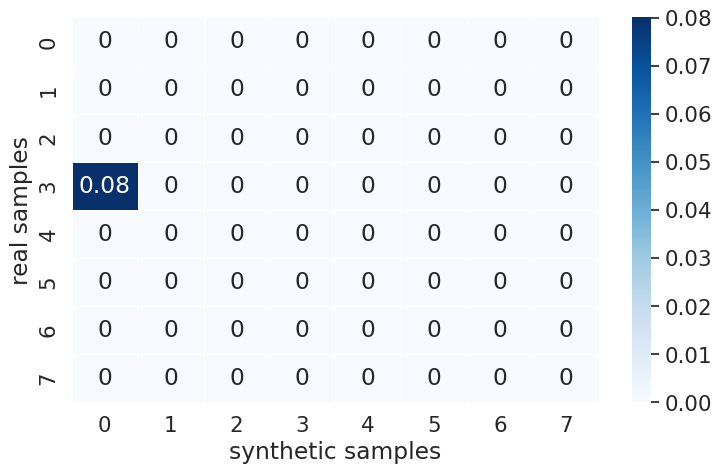

In [21]:
fig, ax = plt.subplots(figsize=(8.5,5))
sns.heatmap(cosine_sim(movie_class0.iloc[:8],sampled_discrete_class0[:8]),xticklabels = 1, yticklabels = 1, 
            cmap='Blues', annot=True,linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [22]:
#Average cosine similarity for class 0
avg_cossim_class0 = np.mean(cosine_sim(movie_class0,sampled_discrete_class0))
avg_cossim_class0

0.007373026494712004

Movie class 1

In [23]:
cosine_sim(movie_class1,sampled_discrete_class1)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

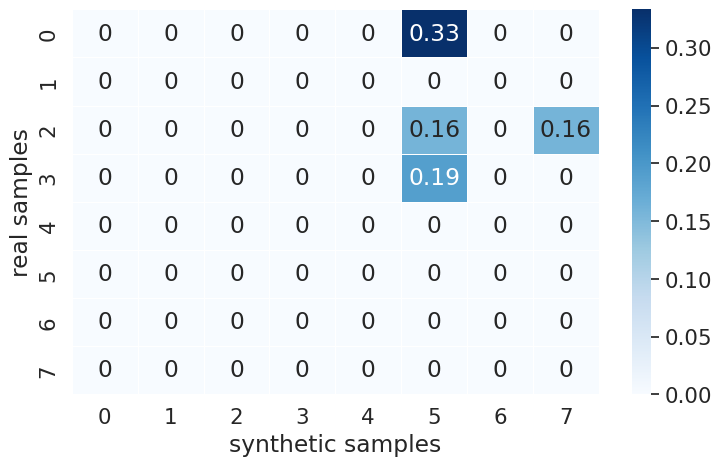

In [24]:
fig, ax = plt.subplots(figsize=(8.5,5))
sns.heatmap(cosine_sim(movie_class1.iloc[:8],sampled_discrete_class1[:8]),xticklabels = 1, yticklabels = 1, 
            cmap='Blues', annot=True,linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [25]:
#Average cosine similarity for class 1
avg_cossim_class1 = np.mean(cosine_sim(movie_class1,sampled_discrete_class1))
avg_cossim_class1

0.014168899384672551

Movie class 2

In [26]:
cosine_sim(movie_class2,sampled_discrete_class2)

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.35355339, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

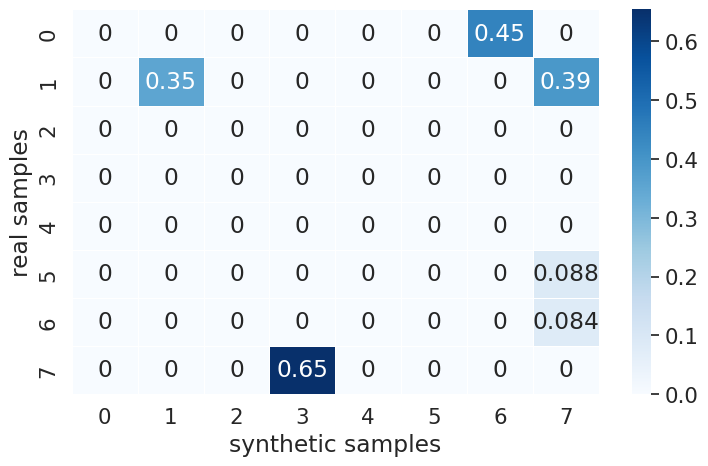

In [27]:
fig, ax = plt.subplots(figsize=(8.5,5))
sns.heatmap(cosine_sim(movie_class2.iloc[:8],sampled_discrete_class2[:8]),xticklabels = 1, yticklabels = 1, 
            cmap='Blues', annot=True,linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [28]:
#Average cosine similarity for class 2
avg_cossim_class2 = np.mean(cosine_sim(movie_class2,sampled_discrete_class2))
avg_cossim_class2

0.00949086580172763

Average cosine similarity for all classes

In [29]:
(avg_cossim_class0 + avg_cossim_class1 +avg_cossim_class2)/3

0.010344263893704062